# Binary And Combination Operators

This notebook is the fifth step in the operator sequence. The earlier notebooks showed how to decompose a graph, compose operators, and filter outputs. Here the emphasis shifts: instead of only selecting existing mapped subgraphs, we build new ones from relationships between subgraphs.

Previous: [05 Filters And Selection](./example_abstract_graph_operators_05_filters_and_selection.ipynb)  
Next: [07 Control Flow And Conditionals](./example_abstract_graph_operators_07_control_flow_and_conditionals.ipynb)


## What this notebook covers

We will look at five related ideas:

1. `combination(...)` builds unions of multiple subgraphs from the same current interpretation graph.
2. `intersection(...)` extracts overlaps between subgraphs from the same current interpretation graph.
3. `binary_combination(...)` combines subgraphs from two different decompositions.
4. `binary_intersection(...)` extracts overlaps between two different decompositions.
5. `union_of_shortest_paths(...)` creates mapped subgraphs by expanding pairs of nodes or regions through the base graph.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import networkx as nx
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')


In [3]:
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings
from abstractgraph.operators import *


def draw(graph, decomposition_function, *, nbits=11, size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(graph, decomposition_function=decomposition_function, nbits=nbits)
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


## The same toy graph

We reuse the same labeled toy graph so it is easier to compare these outputs with notebooks 01 to 03.


Graph with 8 nodes and 9 edges


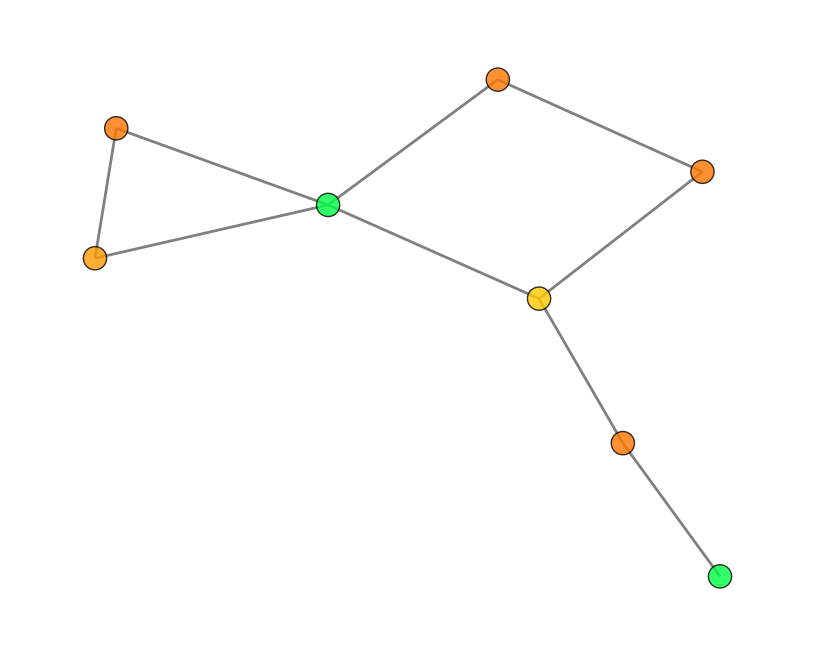

In [4]:
graph = nx.Graph()
graph.add_nodes_from([
    (0, {'label': 'C'}),
    (1, {'label': 'C'}),
    (2, {'label': 'O'}),
    (3, {'label': 'N'}),
    (4, {'label': 'C'}),
    (5, {'label': 'S'}),
    (6, {'label': 'C'}),
    (7, {'label': 'O'}),
])
graph.add_edges_from([
    (0, 1, {'label': 'ring'}),
    (1, 2, {'label': 'ring'}),
    (2, 3, {'label': 'ring'}),
    (3, 0, {'label': 'ring'}),
    (2, 4, {'label': 'bridge'}),
    (4, 5, {'label': 'ring'}),
    (5, 2, {'label': 'ring'}),
    (3, 6, {'label': 'branch'}),
    (6, 7, {'label': 'branch'}),
])

print(graph)
display_graph(graph)


## `combination(...)` on one decomposition

Start from `node()` and combine pairs of nearby node mapped subgraphs. The operator forms a new interpretation node for each valid union whose pairwise distances fall inside the given range.


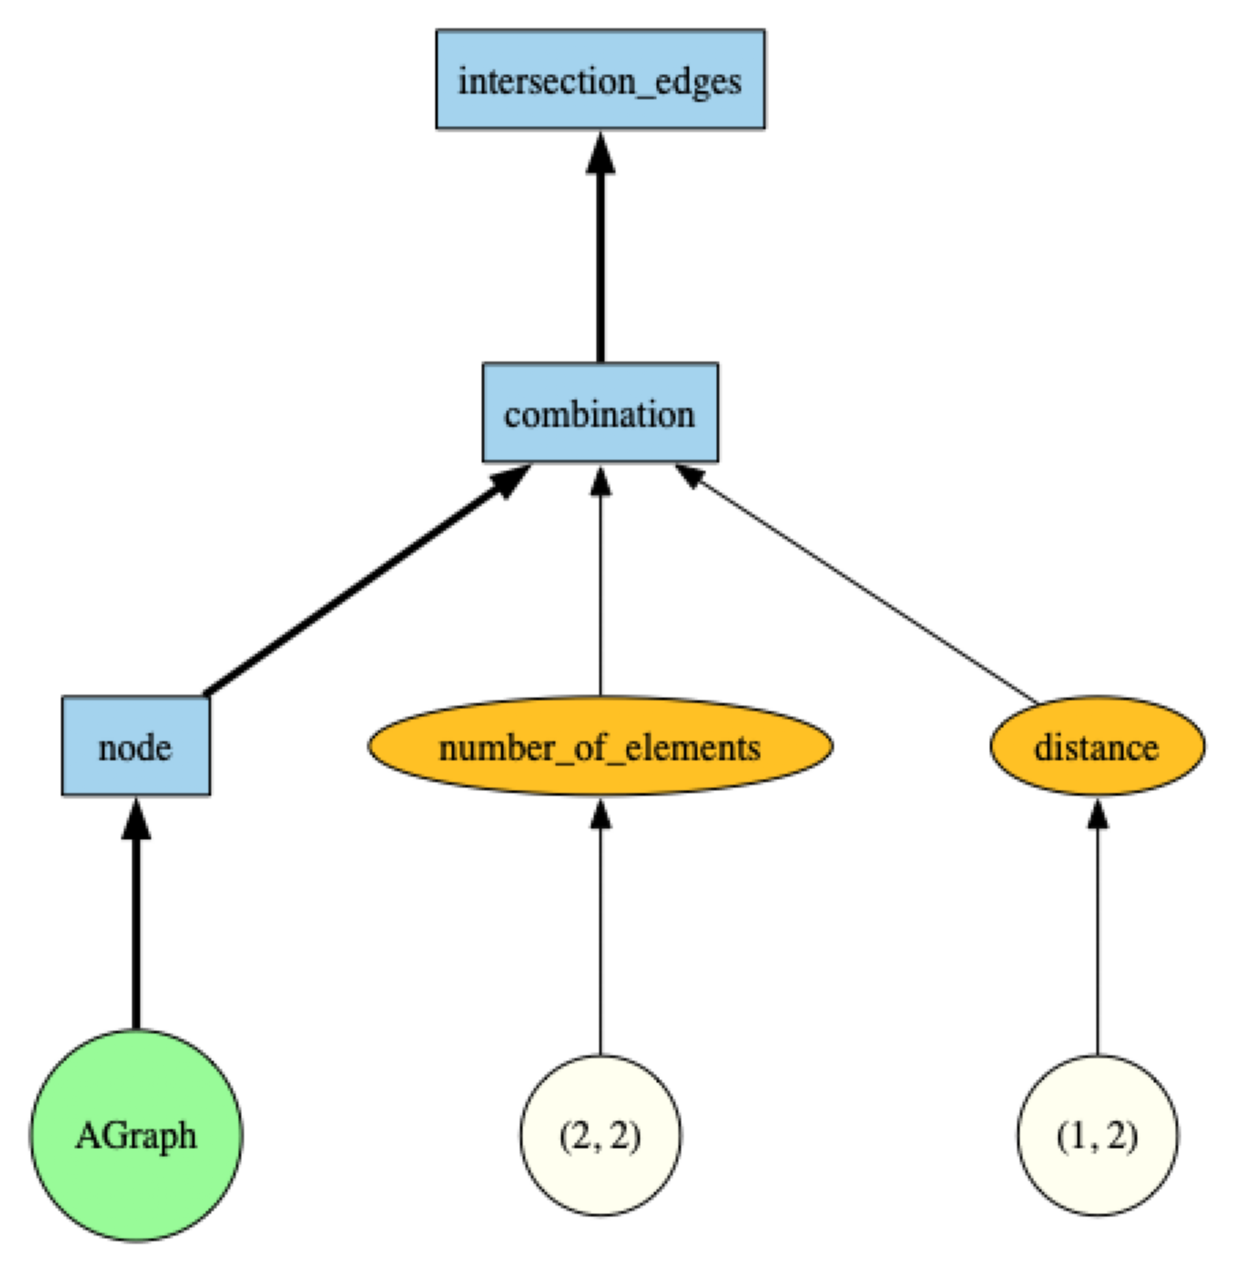

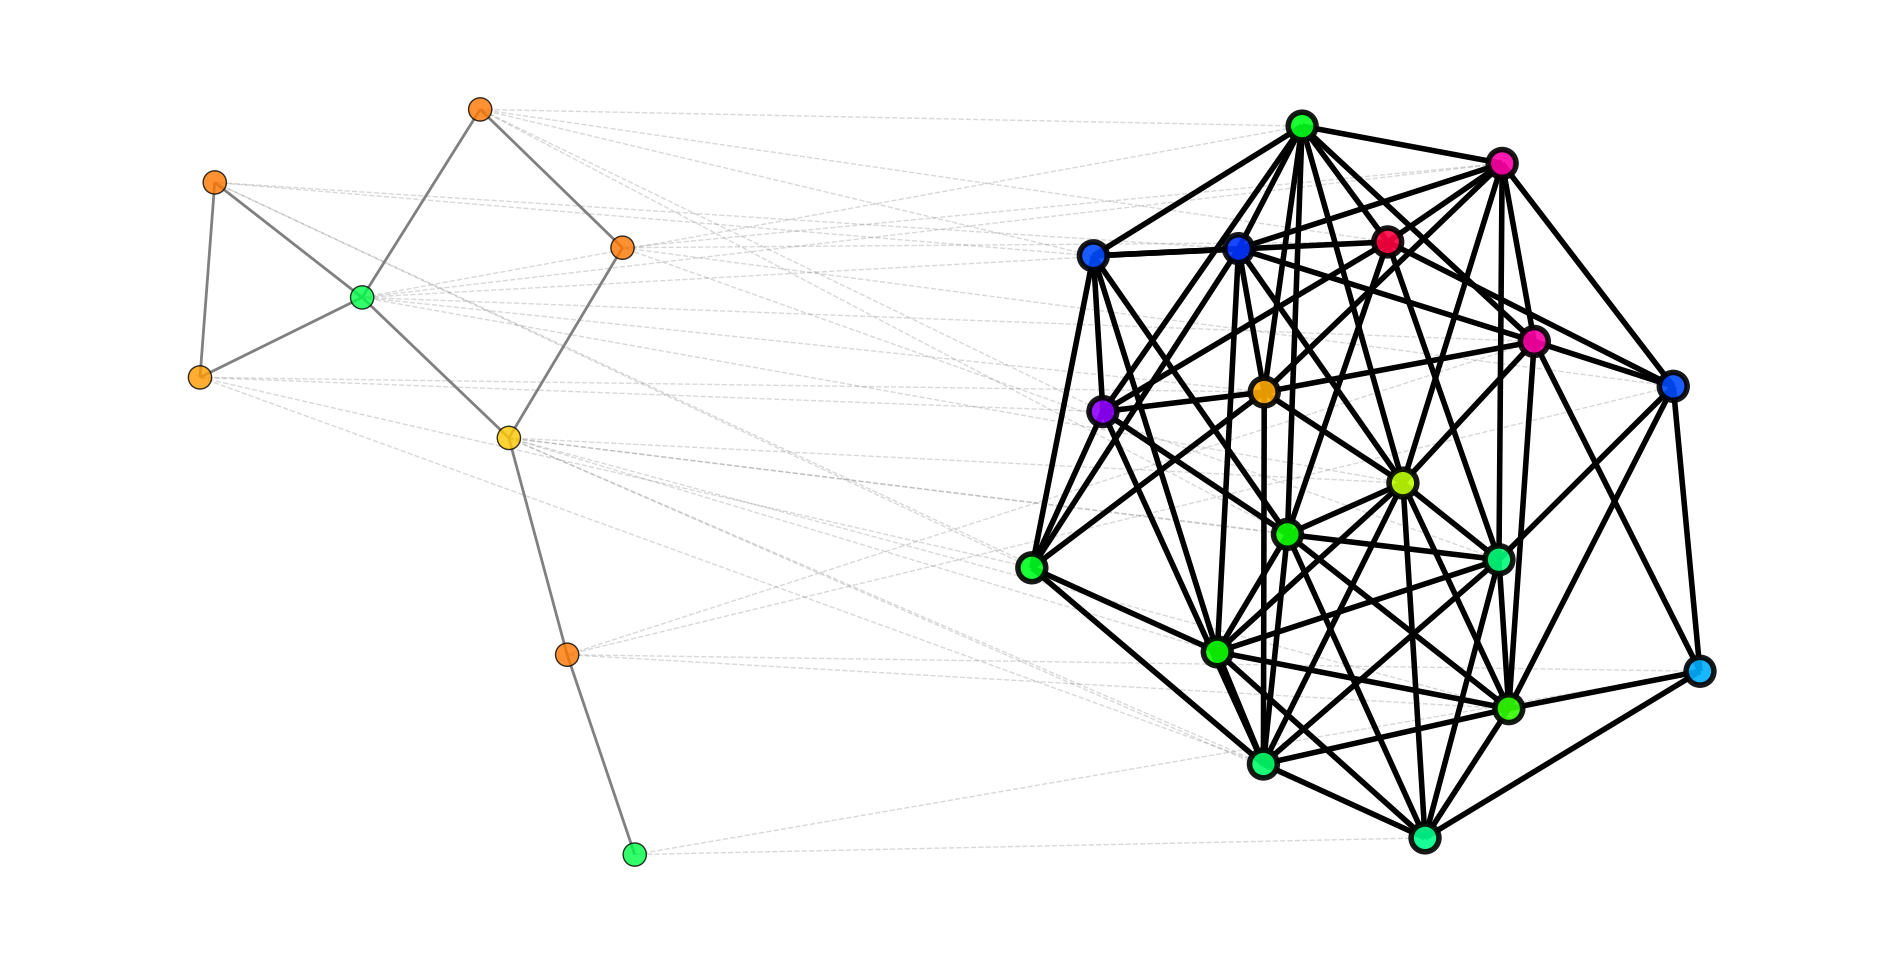

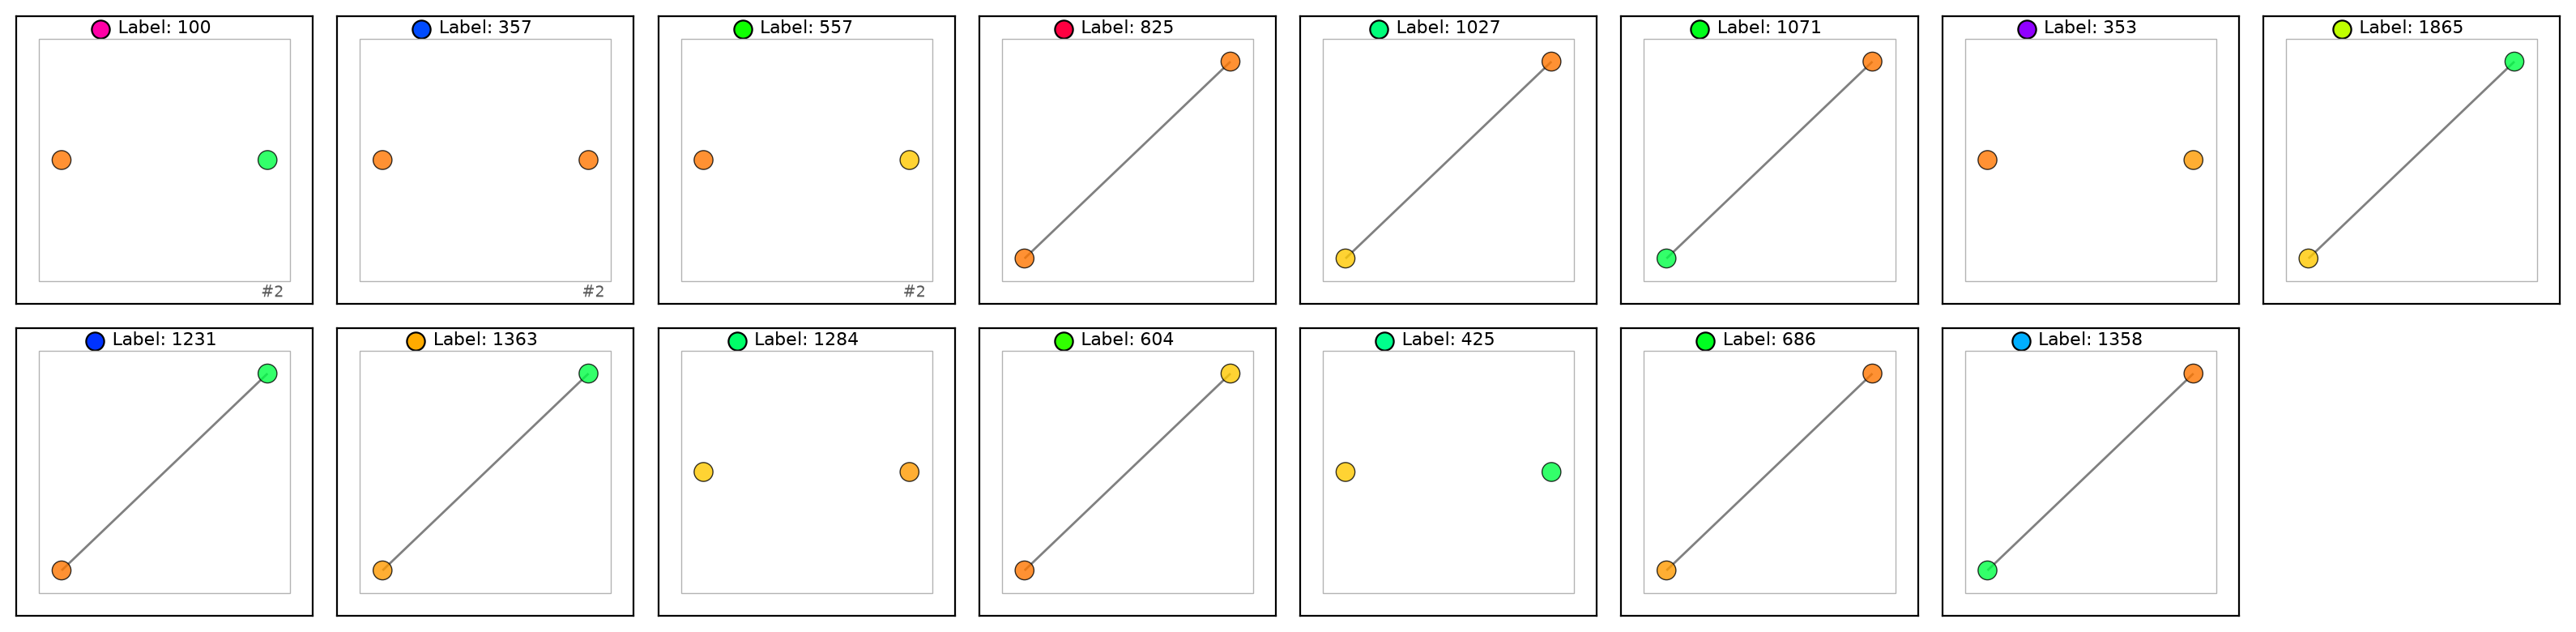

In [5]:
df = compose(
    intersection_edges(),
    combination(number_of_elements=(2, 2), distance=(1, 2)),
    node(),
)
node_combinations_ag = draw(graph, df)


## `combination(...)` after `edge()`

The same operator becomes more expressive when the base units are edges instead of nodes. Now each output interpretation node is a union of two edge-subgraphs.


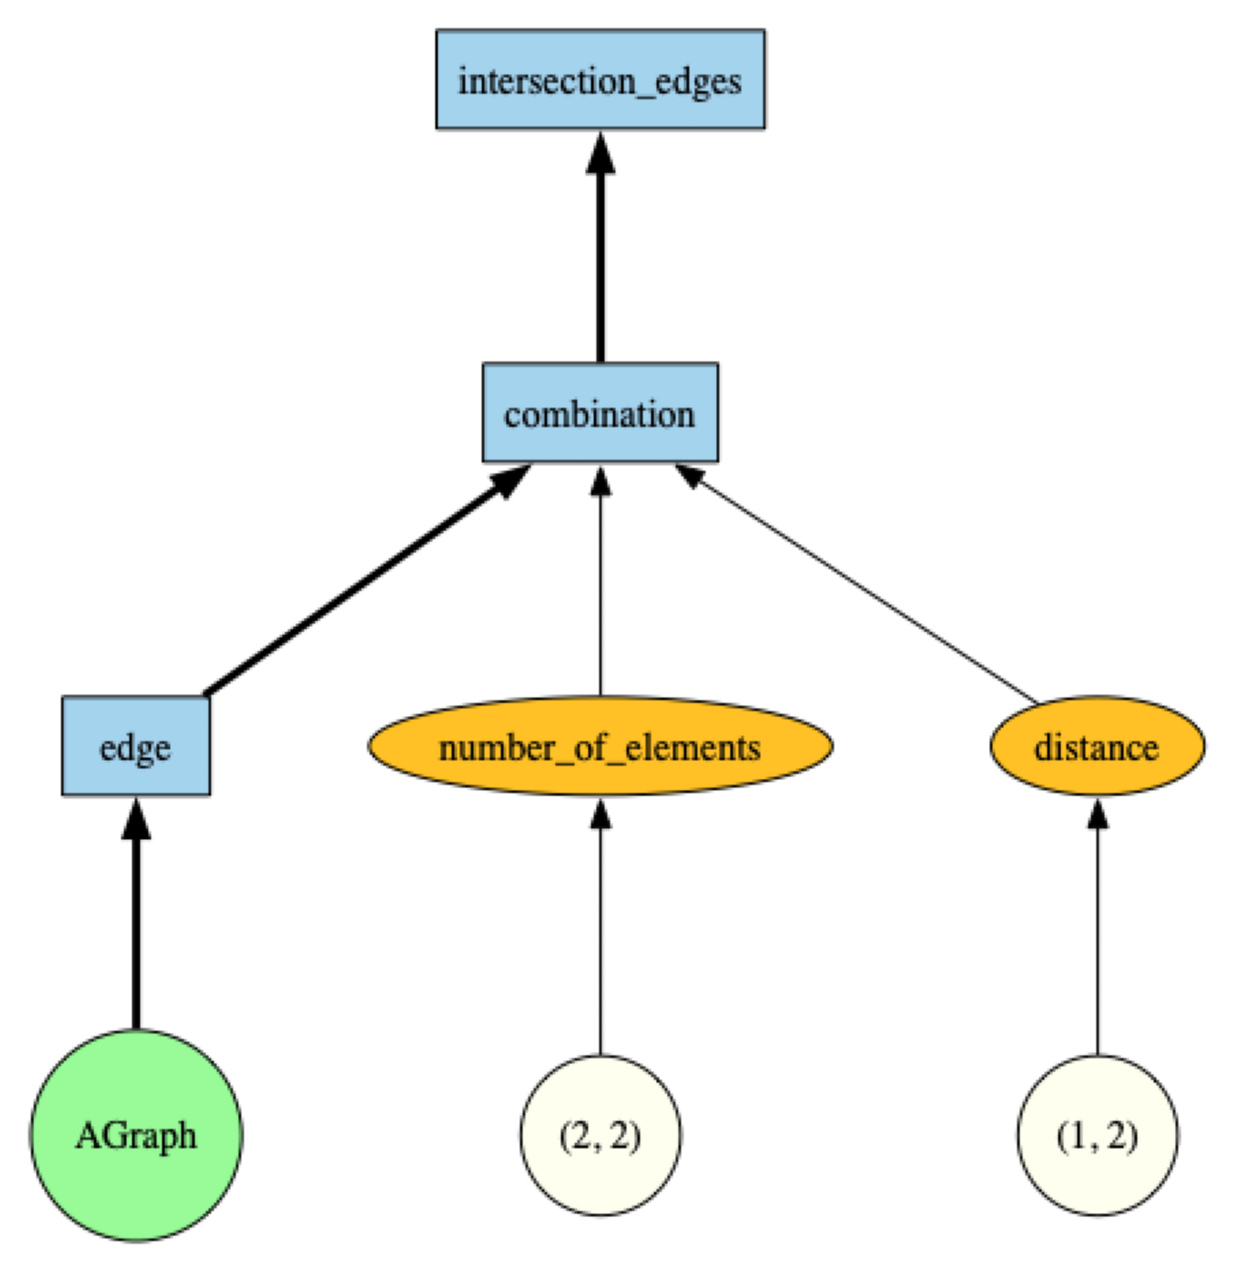

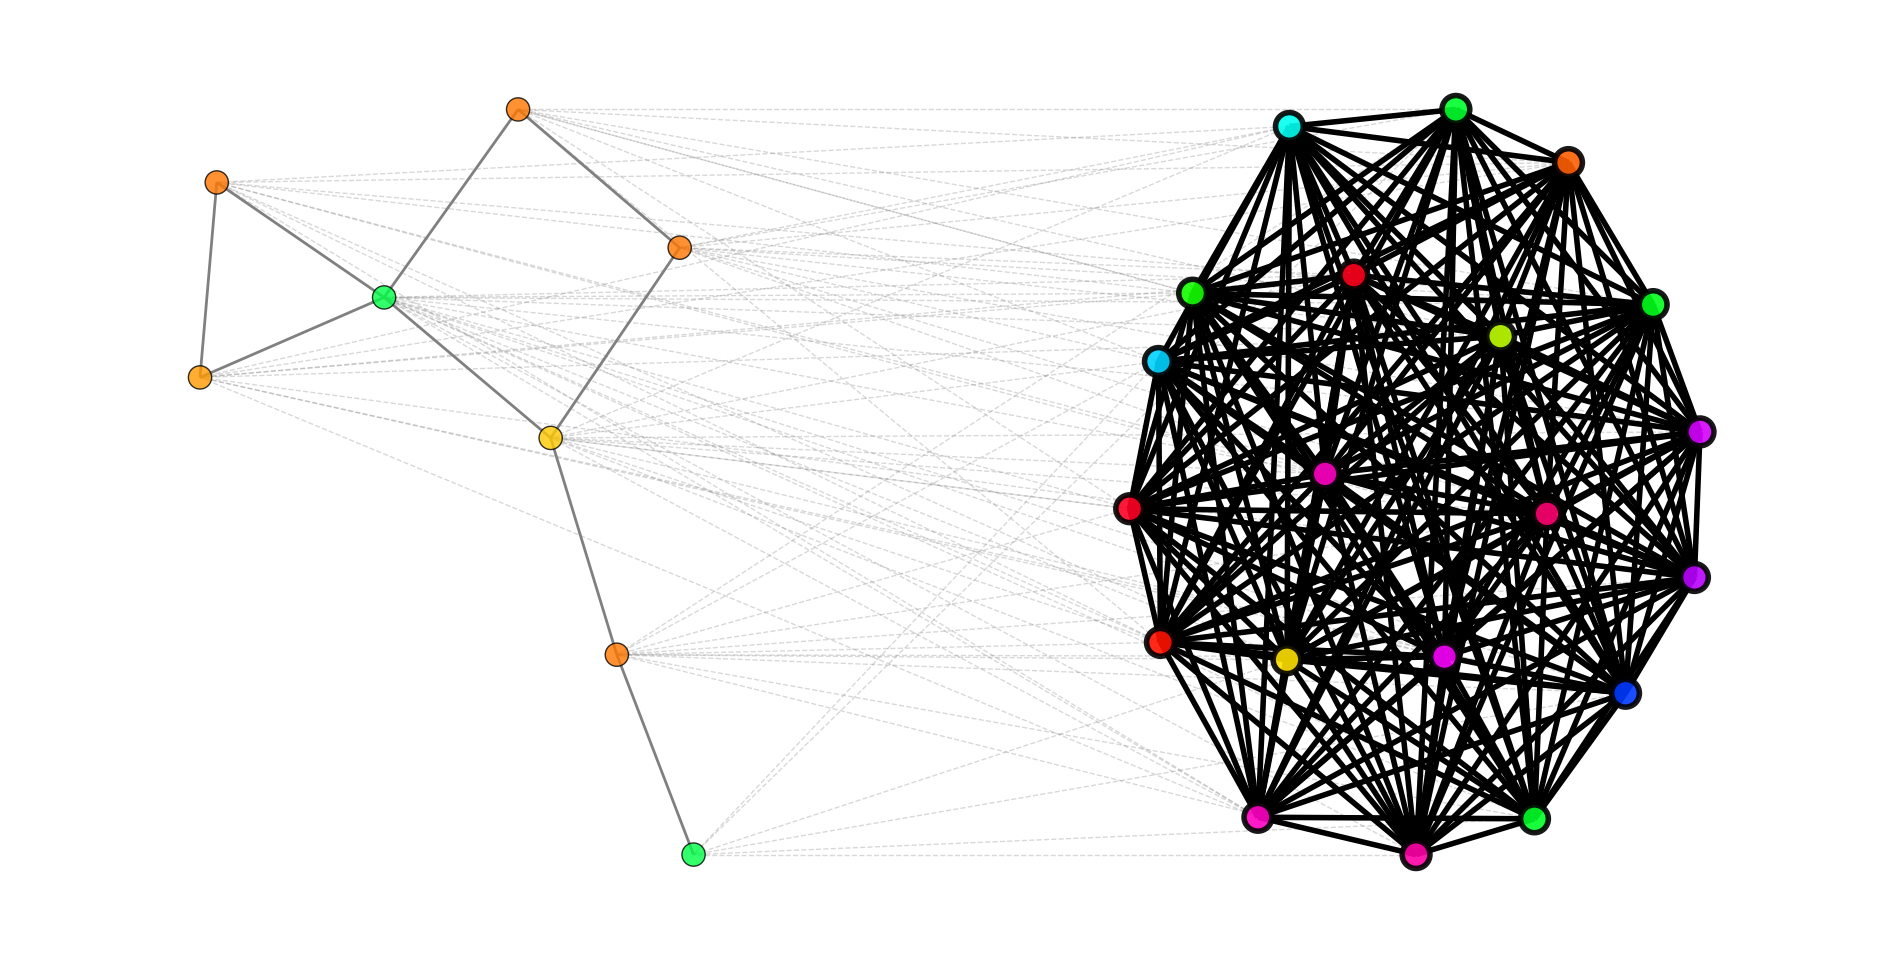

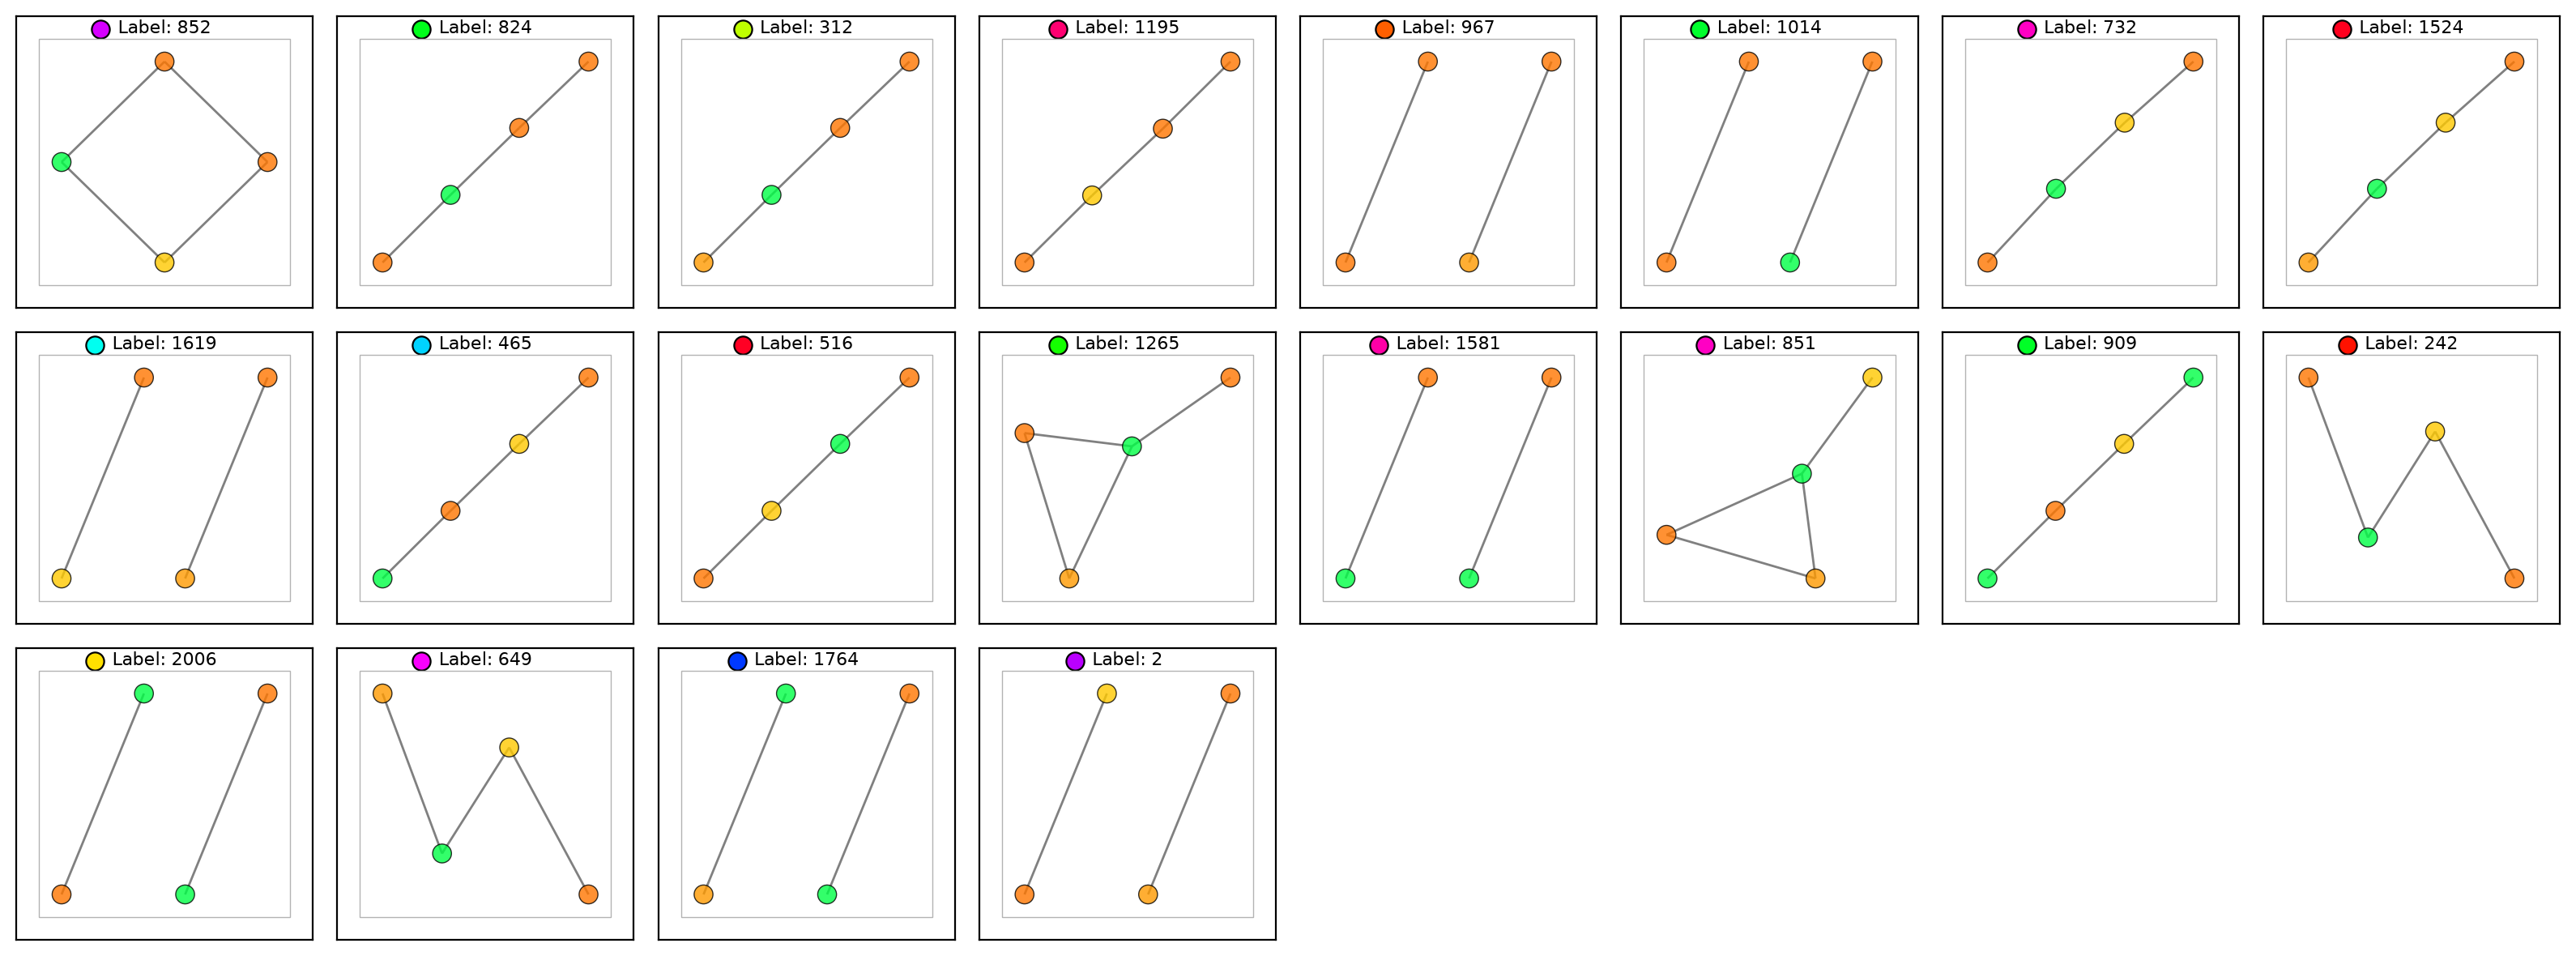

In [6]:
df = compose(
    intersection_edges(),
    combination(number_of_elements=(2, 2), distance=(1, 2)),
    edge(),
)
edge_combinations_ag = draw(graph, df)


## `intersection(...)` within one decomposition

If combinations build larger subgraphs from multiple parts, intersections do the opposite: they recover shared overlap between already-generated subgraphs.


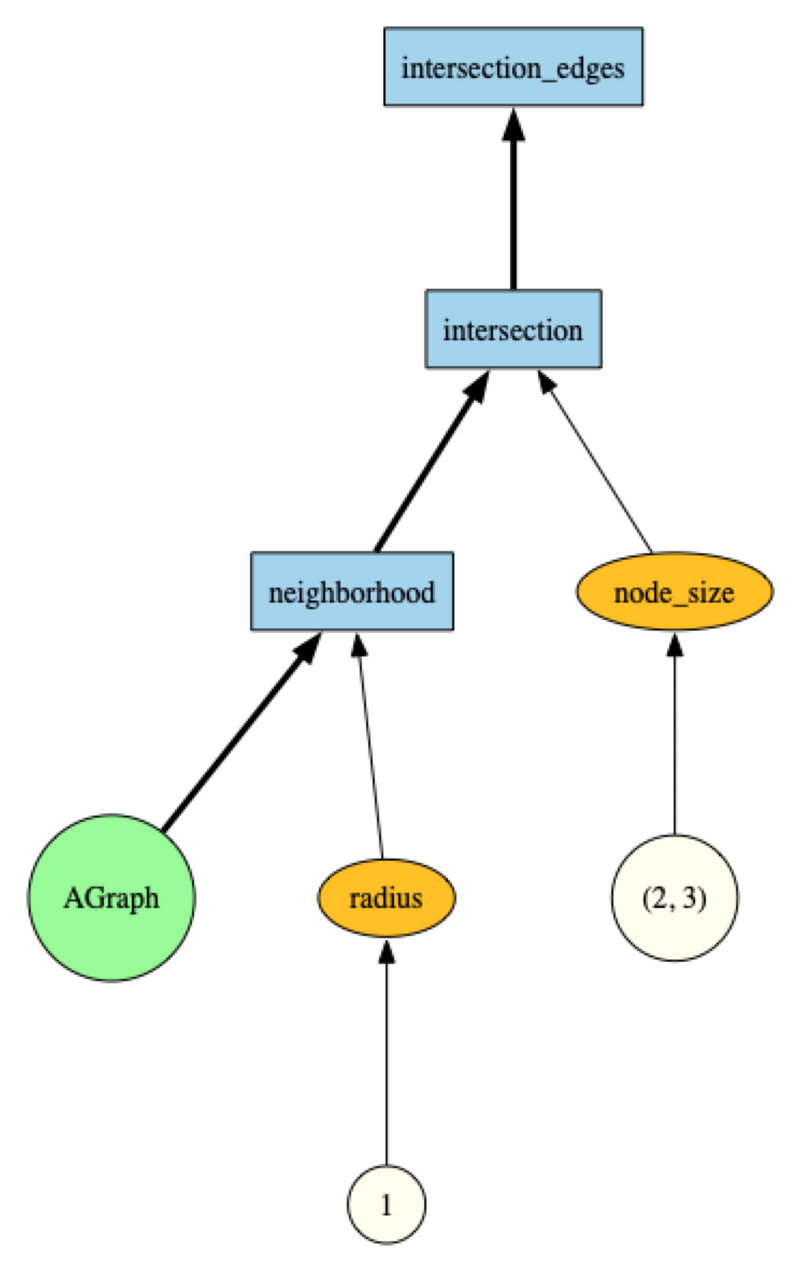

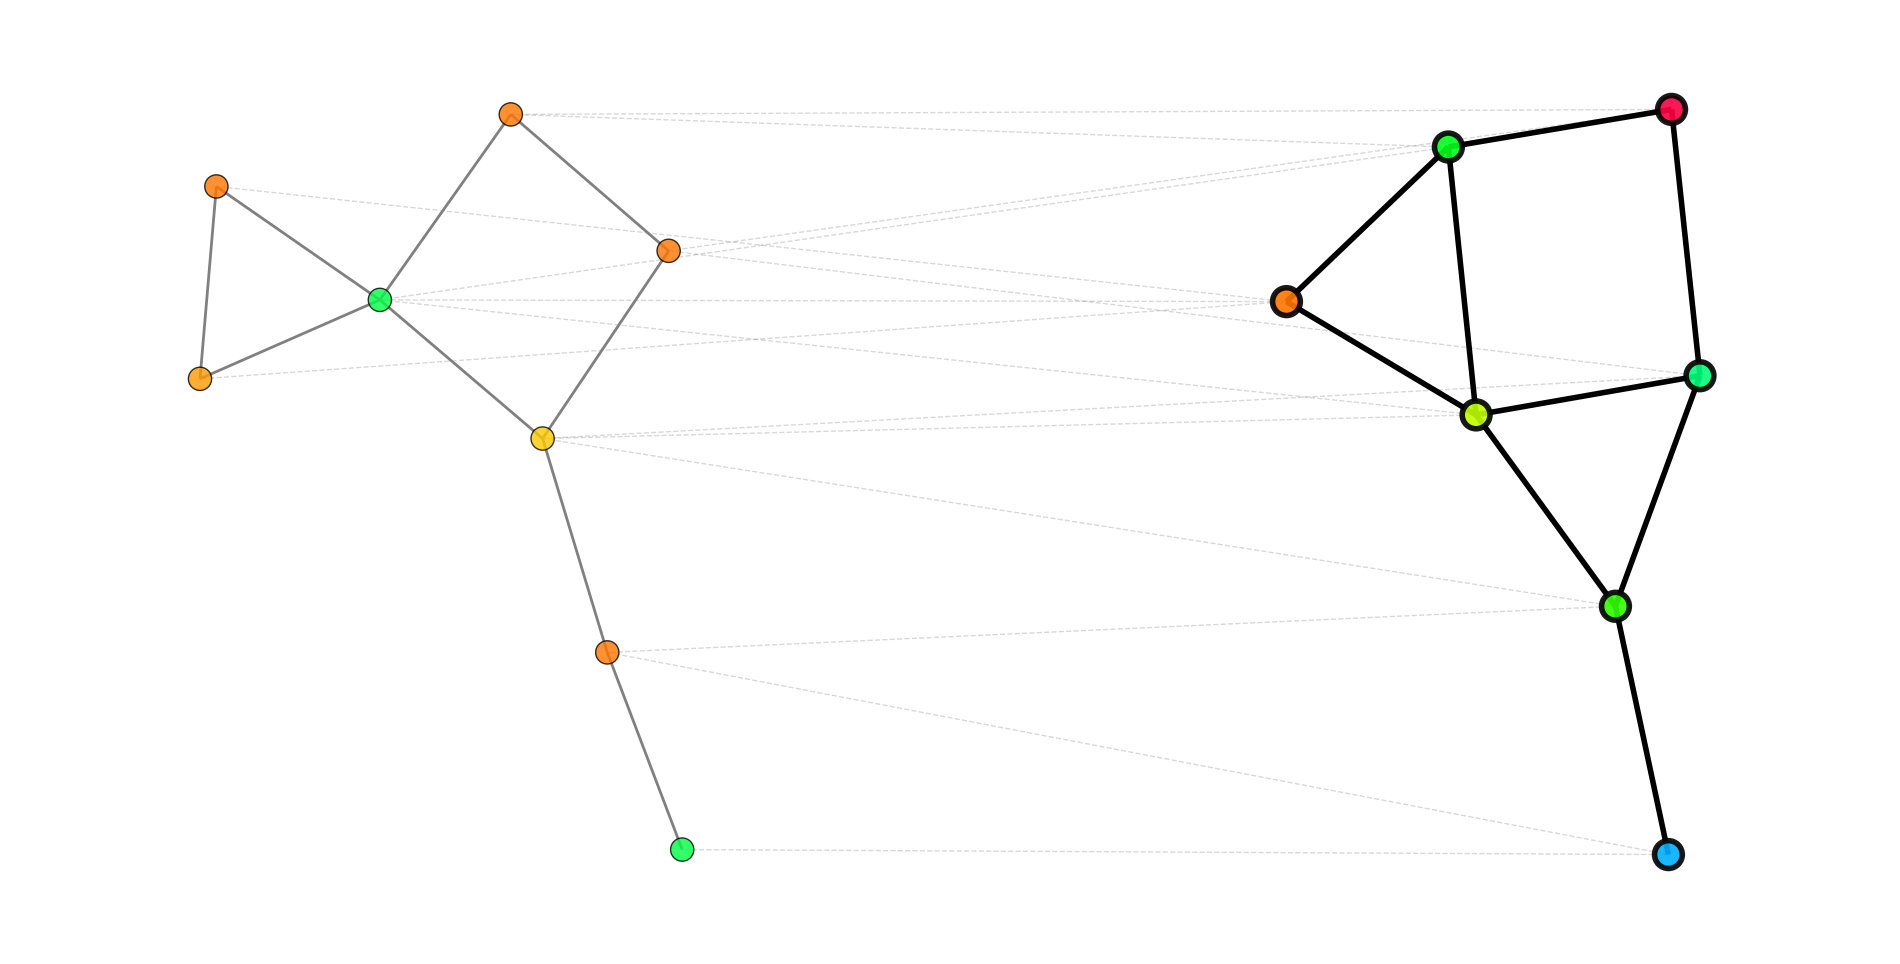

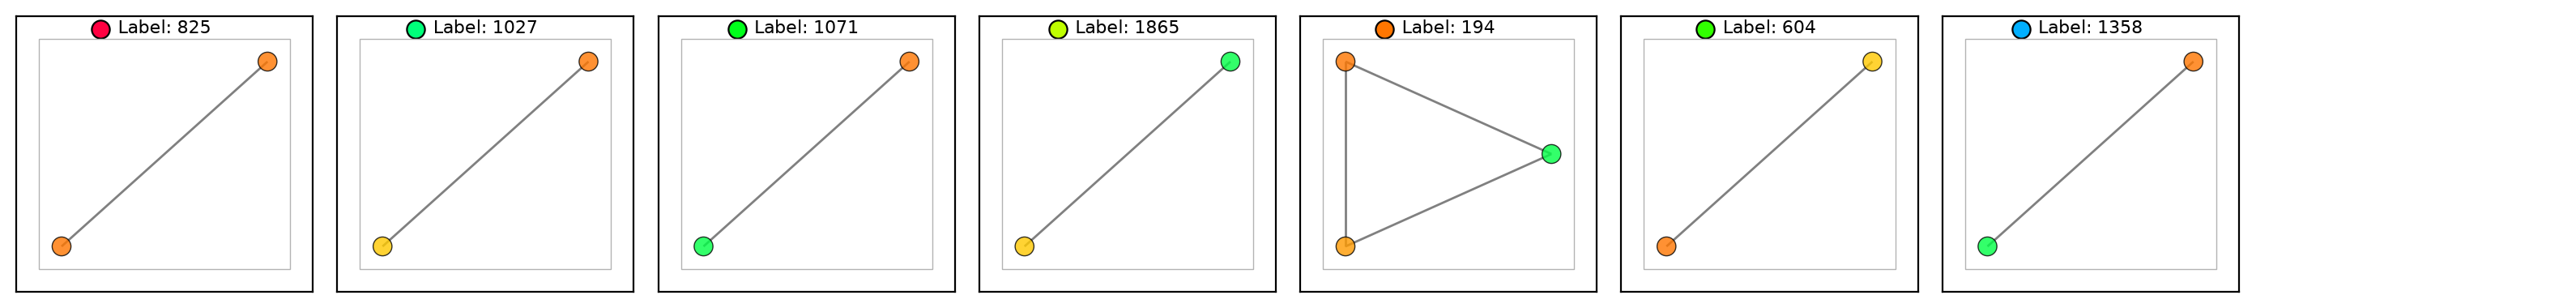

In [7]:
df = compose(
    intersection_edges(),
    intersection(node_size=(2, 3)),
    neighborhood(radius=1),
)
neighborhood_intersections_ag = draw(graph, df)


## `binary_combination(...)` across two decompositions

`binary_combination(...)` does not combine subgraphs from one pool. It takes one subgraph from a first decomposition and one from a second decomposition, then unions them if their distance constraint is satisfied.

`compose_product(...)` is the bridge that runs both decompositions in parallel and hands their outputs to the binary operator.


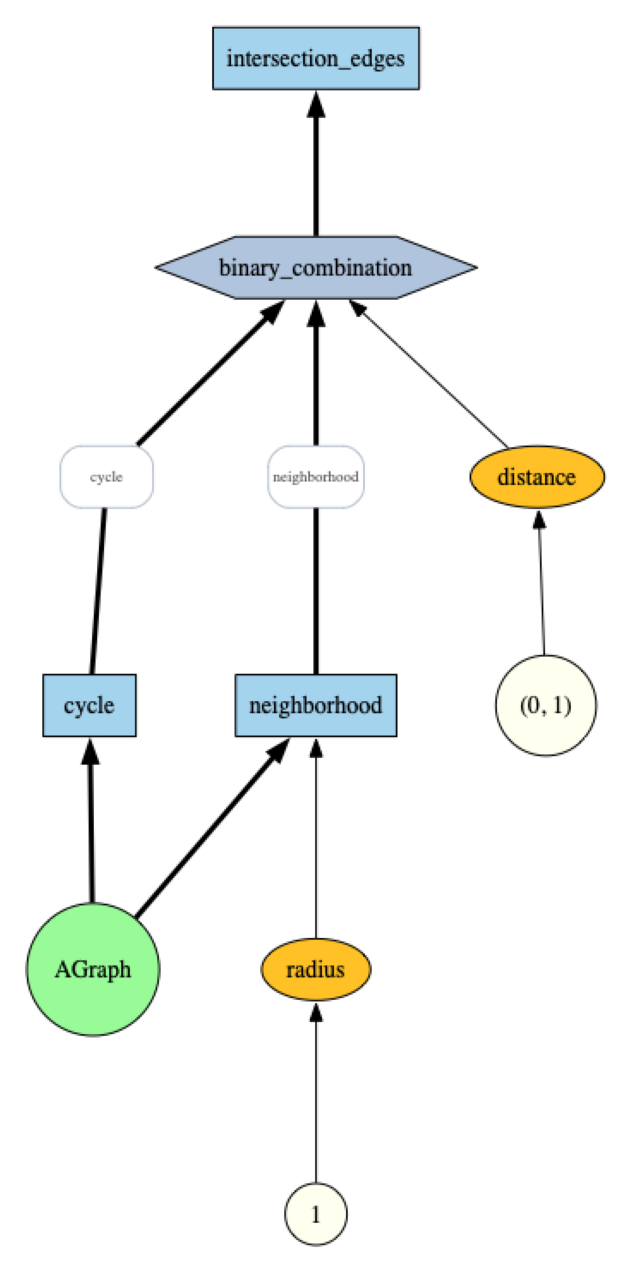

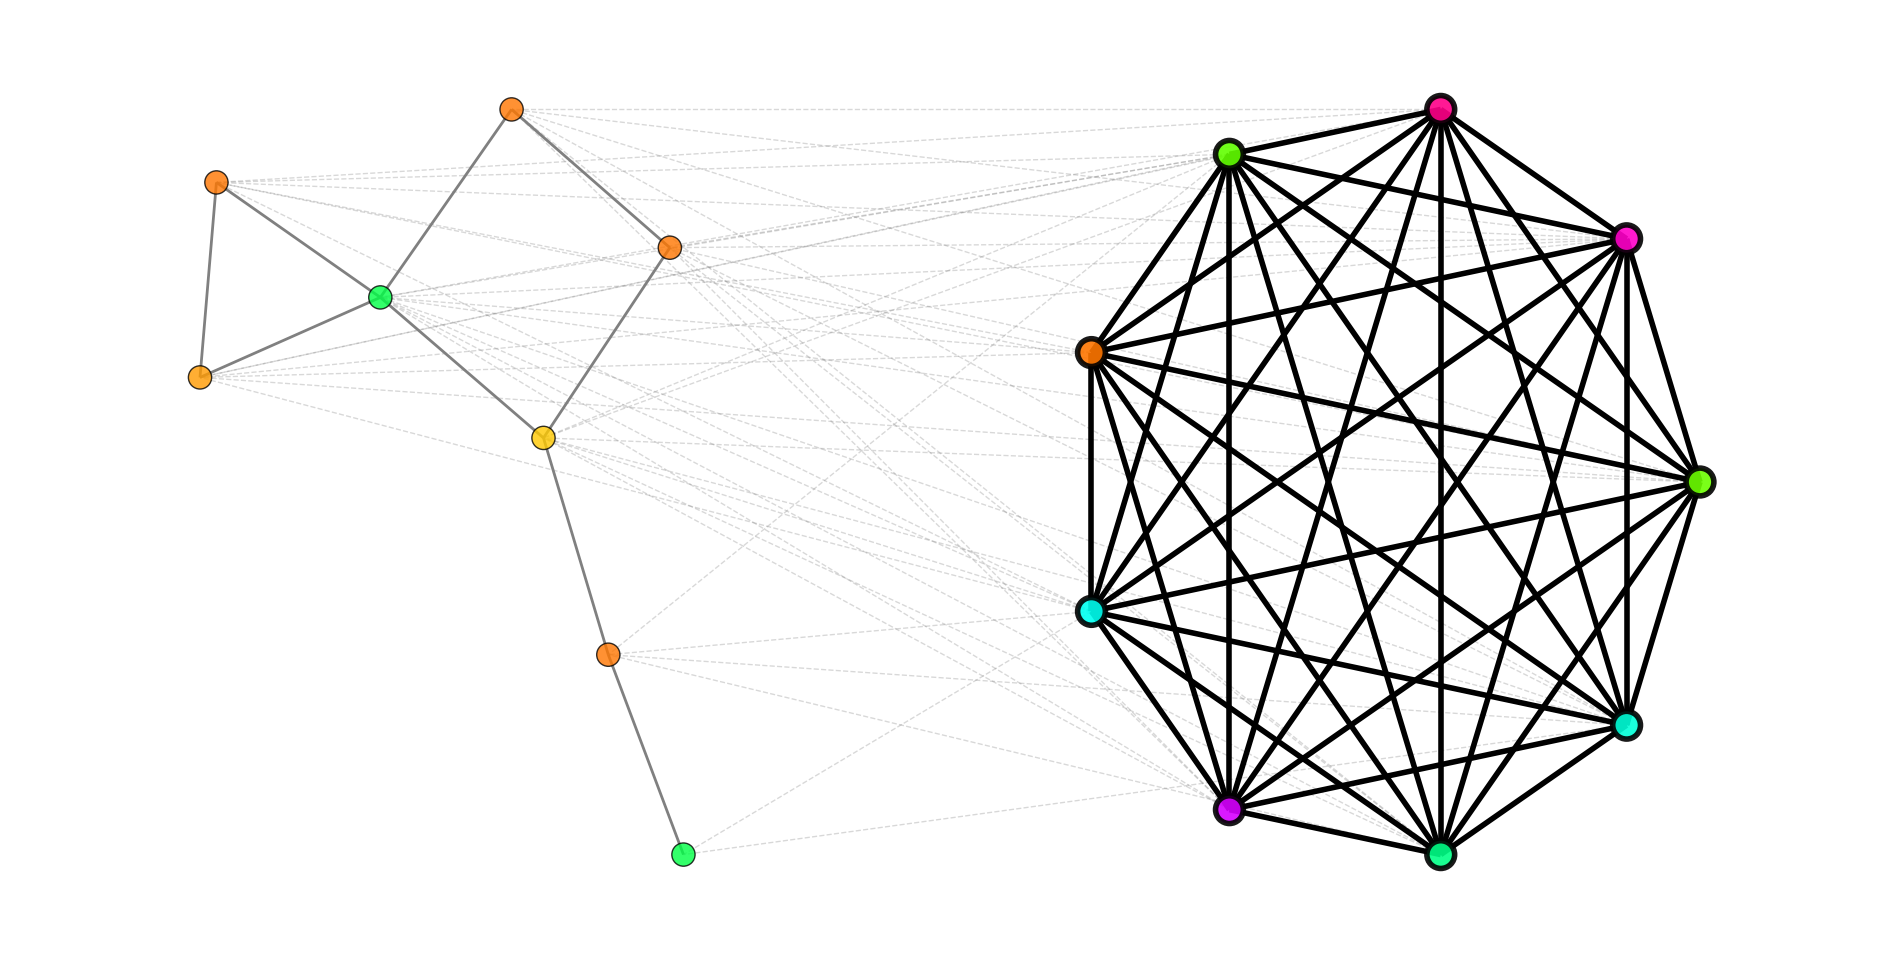

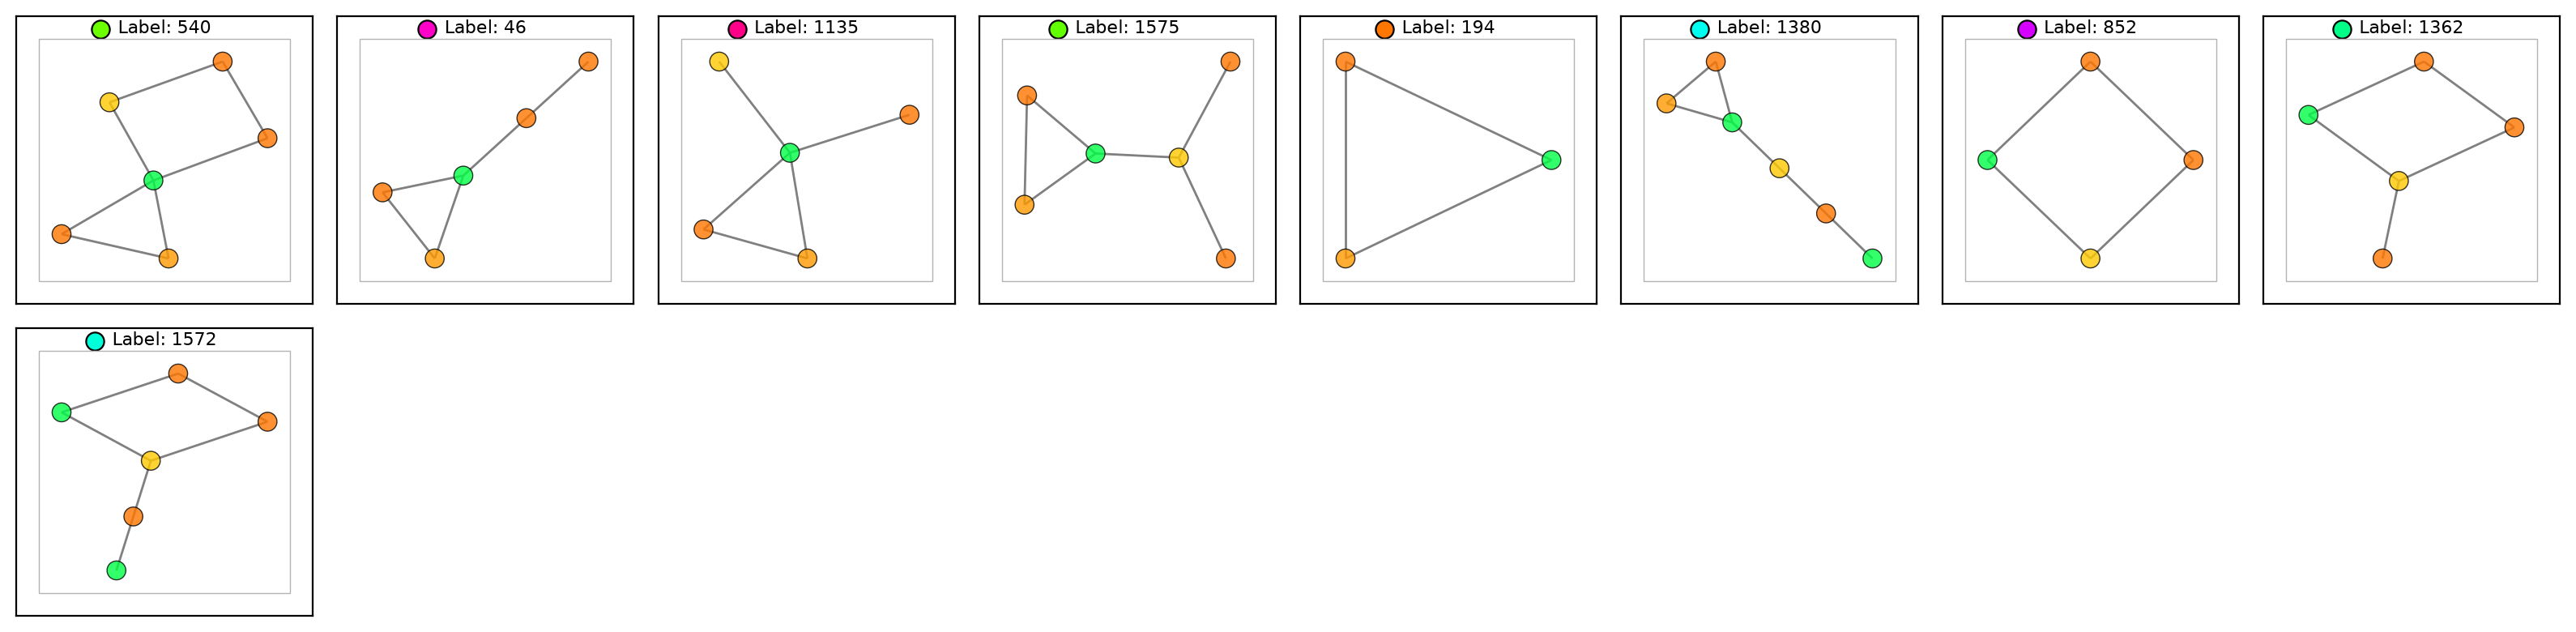

In [8]:
df = compose(
    intersection_edges(),
    compose_product(binary_combination(distance=(0, 1)), cycle(), neighborhood(radius=1)),
)
cycle_neighborhood_binary_ag = draw(graph, df)


## `binary_intersection(...)` across two decompositions

This is the overlap analogue of binary combination: one subgraph comes from each branch, and the output keeps only their intersection.


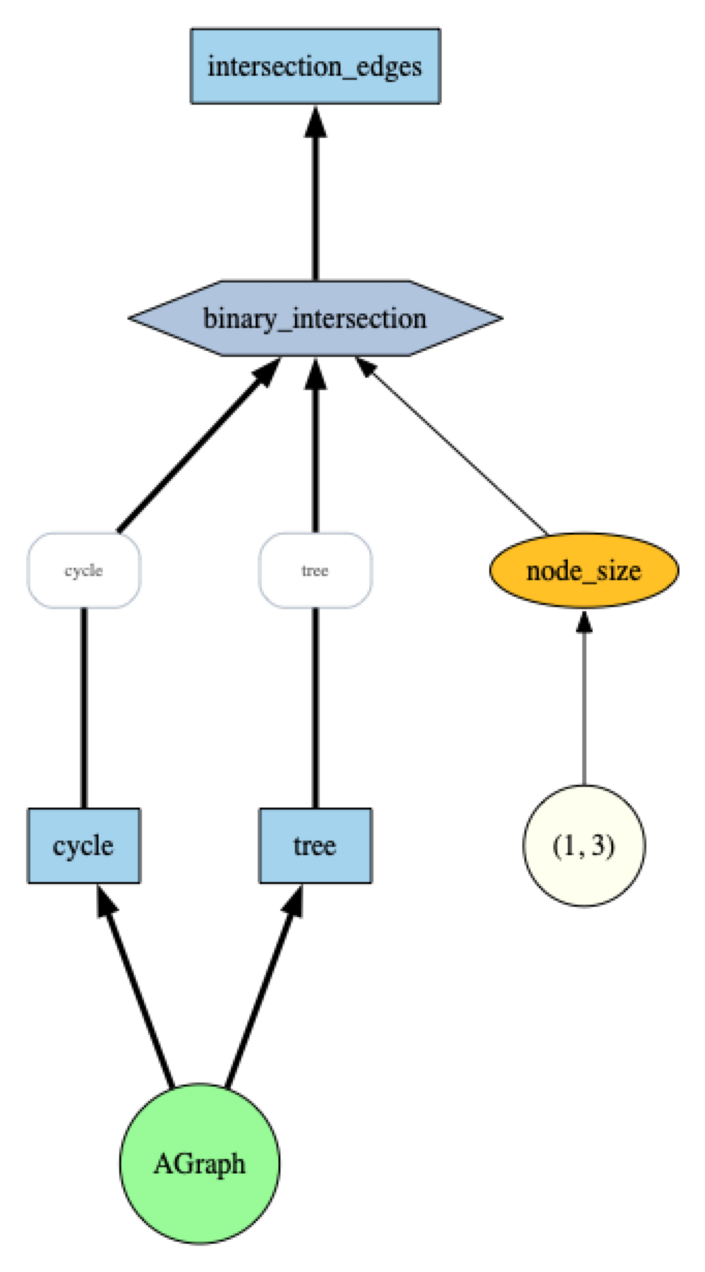

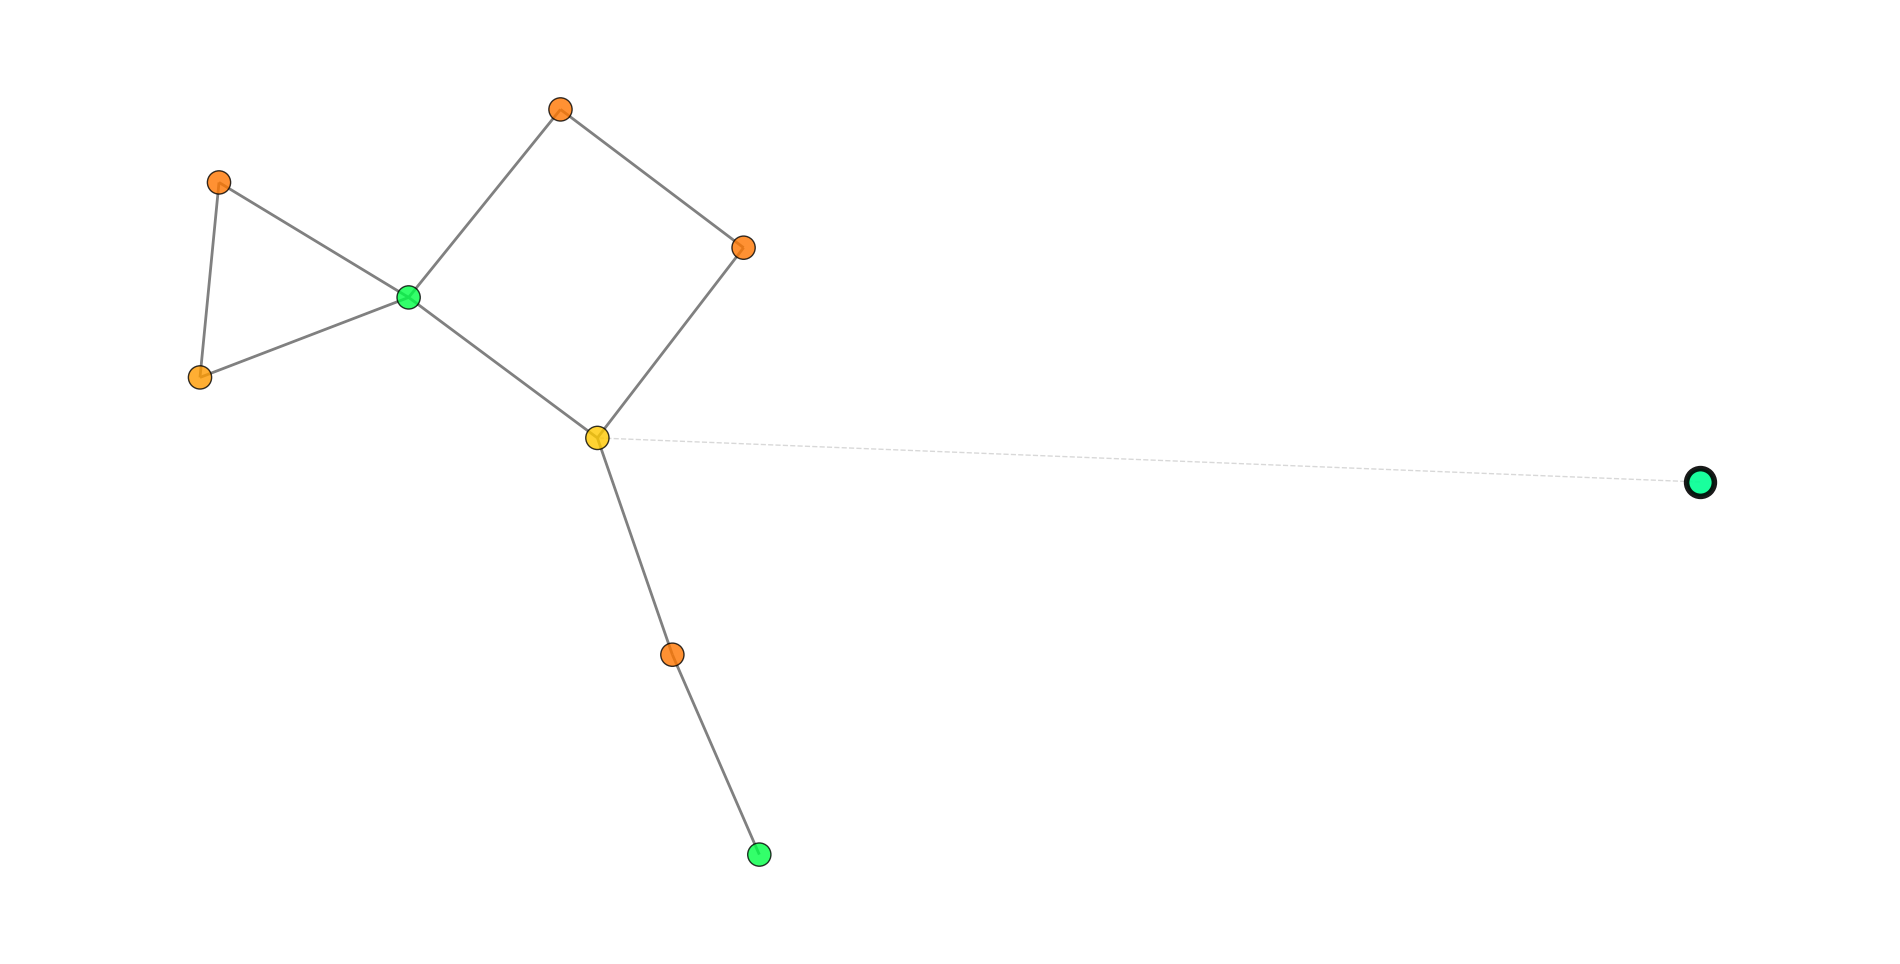

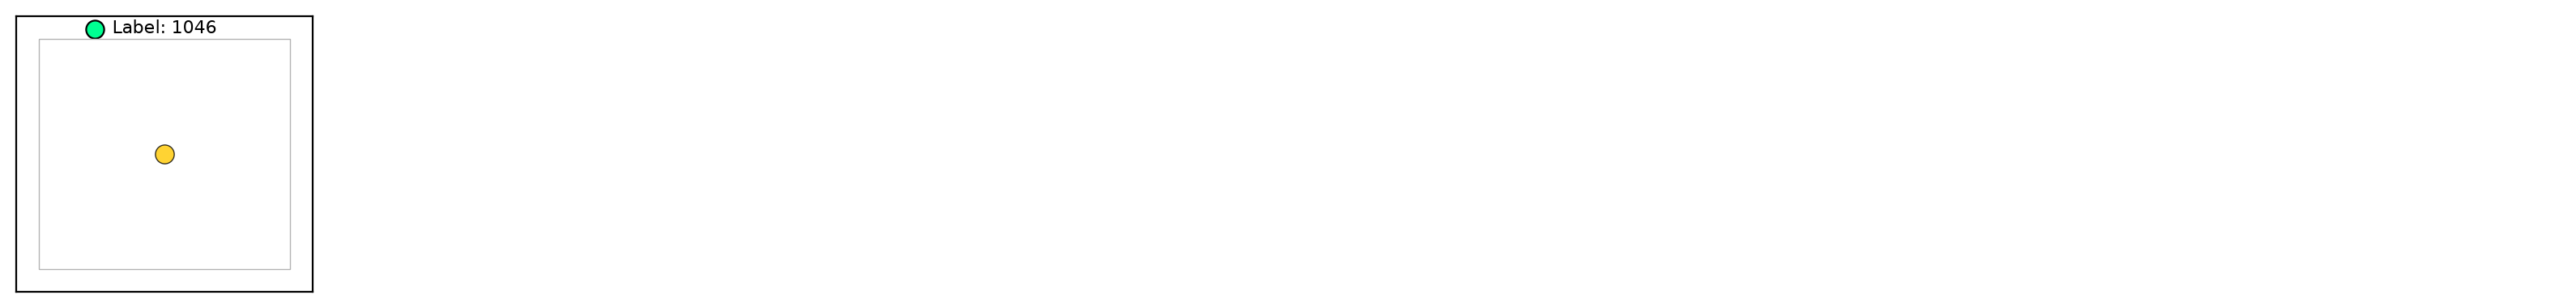

In [9]:
df = compose(
    intersection_edges(),
    compose_product(binary_intersection(node_size=(1, 3)), cycle(), tree()),
)
cycle_tree_binary_intersection_ag = draw(graph, df)


## `union_of_shortest_paths(...)`

This operator expands associated regions through the base graph by collecting shortest paths whose lengths fall inside a target range. Starting from a connected component gives it a large enough base region to be informative.


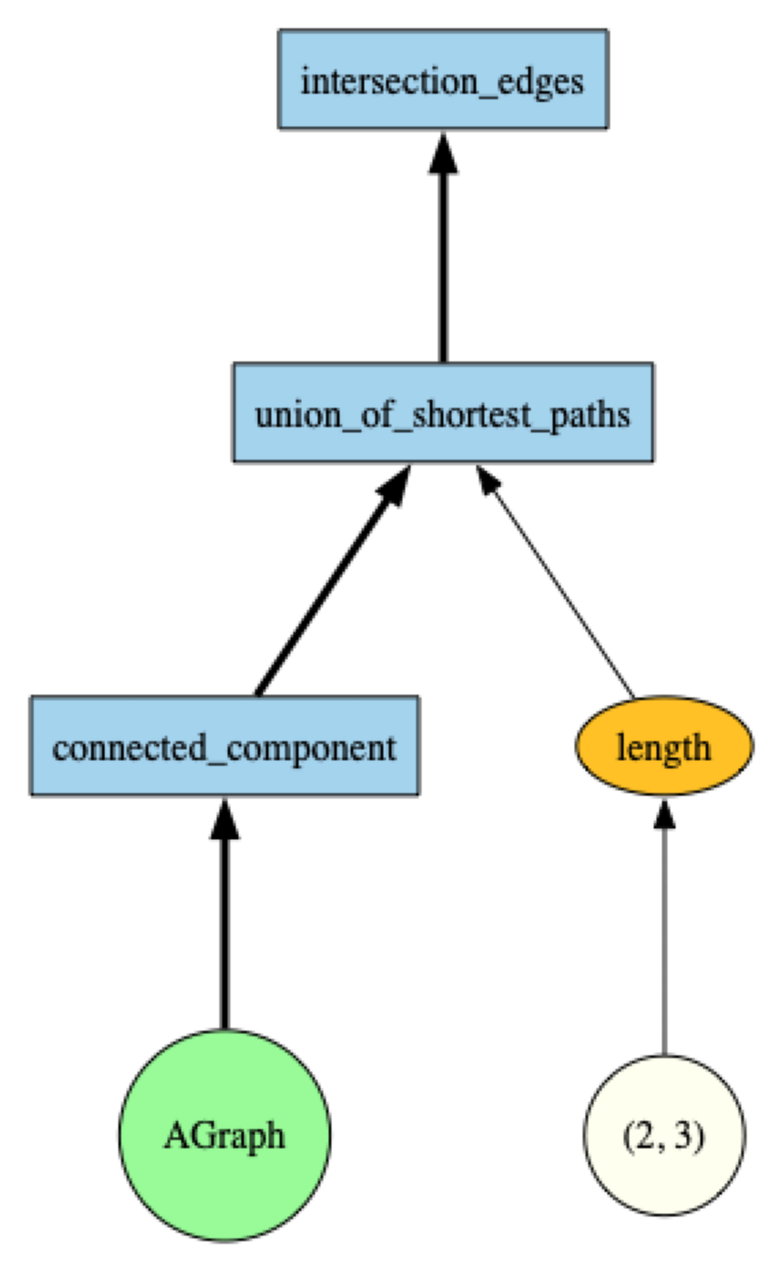

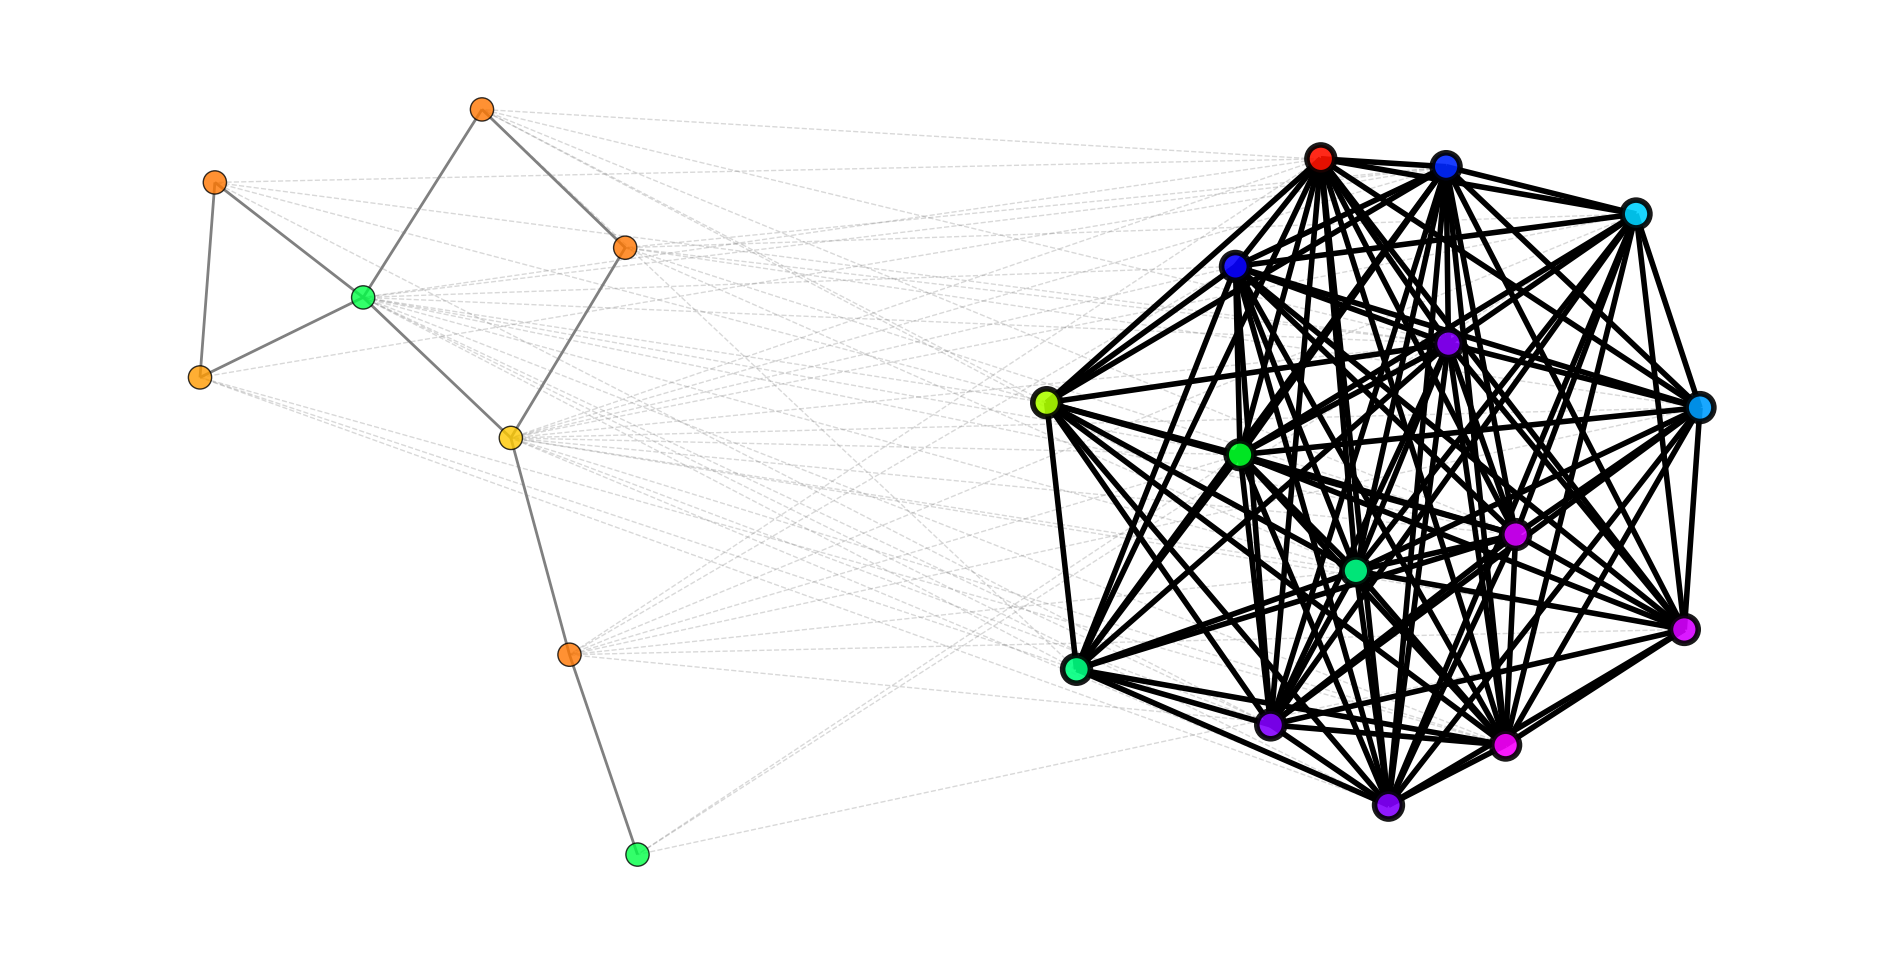

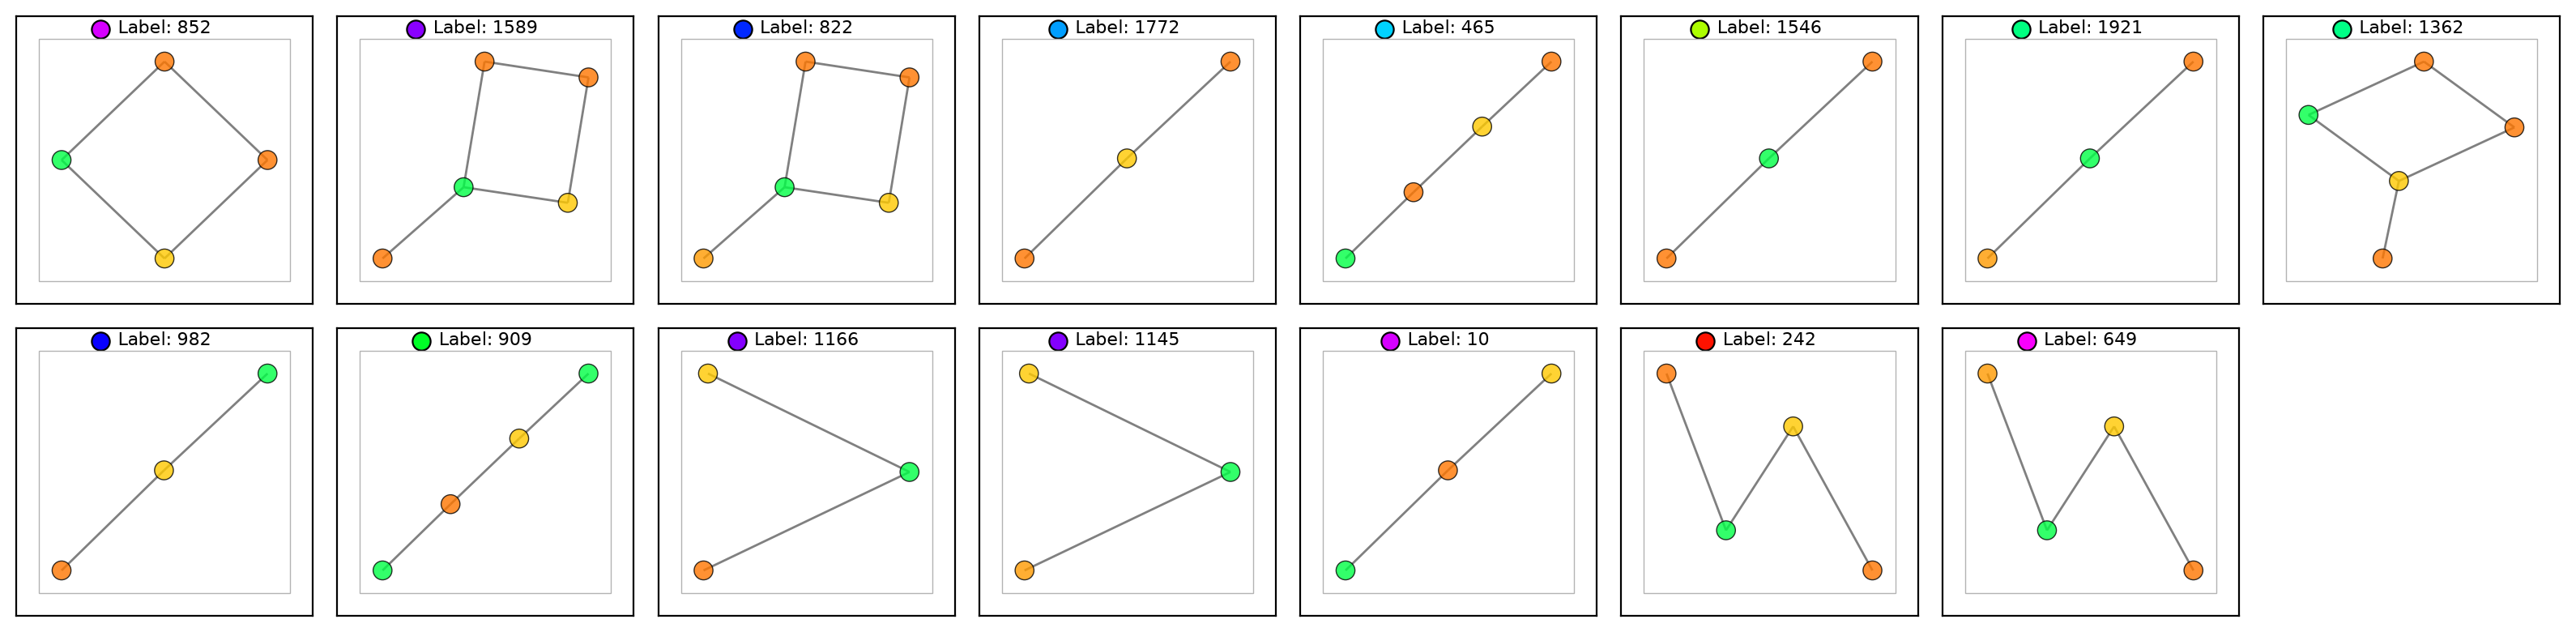

In [10]:
df = compose(
    intersection_edges(),
    union_of_shortest_paths(length=(2, 3)),
    connected_component(),
)
shortest_path_union_ag = draw(graph, df)


## Reading the differences

A useful way to compare these operators is:

- `combination(...)`: union within one current vocabulary
- `intersection(...)`: overlap within one current vocabulary
- `binary_combination(...)`: union across two different vocabularies
- `binary_intersection(...)`: overlap across two different vocabularies
- `union_of_shortest_paths(...)`: graph expansion driven by shortest-path structure rather than direct union/intersection of existing subgraphs


## Summary

This notebook introduced the first operators that genuinely synthesize new mapped subgraphs from relationships between other subgraphs. That is the transition point from simple decomposition toward richer structural programs.

A natural next notebook is `05_control_flow_and_conditionals.ipynb`, where the focus shifts from static operator chains to branching and iterative graph programs.

Previous: [05 Filters And Selection](./example_abstract_graph_operators_05_filters_and_selection.ipynb)  
Next: [07 Control Flow And Conditionals](./example_abstract_graph_operators_07_control_flow_and_conditionals.ipynb)
